<a href="https://colab.research.google.com/github/kalyana-samarasinghe/emotion-classification-distilbert/blob/main/notebooks/emotion_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install -q transformers datasets evaluate

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
GPU: Tesla T4


In [23]:
from datasets import load_dataset

#Download straight from huggingface.co/datasets/dair-ai/emotion
raw = load_dataset("dair-ai/emotion")

print(raw)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [24]:
label_names = raw["train"].features["label"].names
print("Labels:", label_names)

# What a single example actually looks like
print("\nExample 0:", raw["train"][0])
print("Decoded label:", label_names[raw["train"][0]["label"]])

# Class balance - always check this before you trust an accuracy number
from collections import Counter
counts = Counter(raw["train"]["label"])
print("\nTraining set distribution:")
for i, name in enumerate(label_names):
    print(f"  {name:10s} {counts[i]:5d}  ({counts[i]/len(raw['train'])*100:.1f}%)")

Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Example 0: {'text': 'i didnt feel humiliated', 'label': 0}
Decoded label: sadness

Training set distribution:
  sadness     4666  (29.2%)
  joy         5362  (33.5%)
  love        1304  (8.2%)
  anger       2159  (13.5%)
  fear        1937  (12.1%)
  surprise     572  (3.6%)


In [43]:
# ===== CELL 3: data pipeline (replaces all earlier tokenizer/loader cells) =====
from transformers import AutoTokenizer, DataCollatorWithPadding
from torch.utils.data import DataLoader

MODEL_NAME = "distilbert-base-uncased"
BATCH_SIZE = 32

label_names = raw["train"].features["label"].names
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tokenized = raw.map(tokenize, batched=True,
                    remove_columns=["text"],
                    load_from_cache_file=False)
tokenized = tokenized.rename_column("label", "labels")

if "token_type_ids" in tokenized["train"].column_names:
    tokenized = tokenized.remove_columns("token_type_ids")

# no set_format - the collator handles tensor conversion
assert set(tokenized["train"].column_names) == {"labels", "input_ids", "attention_mask"}, \
    tokenized["train"].column_names

collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_loader = DataLoader(tokenized["train"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
val_loader   = DataLoader(tokenized["validation"], batch_size=BATCH_SIZE, collate_fn=collator)
test_loader  = DataLoader(tokenized["test"], batch_size=BATCH_SIZE, collate_fn=collator)

batch = next(iter(train_loader))
print({k: (tuple(v.shape), v.dtype) for k, v in batch.items()})

Map: 100%|##########| 16000/16000 [00:00<?, ? examples/s]

Map: 100%|##########| 2000/2000 [00:00<?, ? examples/s]

Map: 100%|##########| 2000/2000 [00:00<?, ? examples/s]

{'labels': ((32,), torch.int64), 'input_ids': ((32, 47), torch.int64), 'attention_mask': ((32, 47), torch.int64)}


In [44]:
print("raw:      ", {k: len(v) for k, v in raw.items()})
print("tokenized:", {k: len(v) for k, v in tokenized.items()})

raw:       {'train': 16000, 'validation': 2000, 'test': 2000}
tokenized: {'train': 16000, 'validation': 2000, 'test': 2000}


In [45]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label={i: n for i, n in enumerate(label_names)},
    label2id={n: i for i, n in enumerate(label_names)},
).to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 67.0M


In [46]:
from torch.optim import AdamW
from transformers import get_scheduler

EPOCHS, LR = 2, 2e-5

optimizer = AdamW(model.parameters(), lr=LR)
num_training_steps = EPOCHS * len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer,
                             num_warmup_steps=0,
                             num_training_steps=num_training_steps)
print("Optimizer steps:", num_training_steps)

Optimizer steps: 1000


In [47]:
from tqdm.auto import tqdm

def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            batch.pop("token_type_ids", None)
            outputs = model(**batch)
            loss_sum += outputs.loss.item() * batch["labels"].size(0)
            correct += (outputs.logits.argmax(-1) == batch["labels"]).sum().item()
            total += batch["labels"].size(0)
    return loss_sum / total, correct / total


history = []

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        batch.pop("token_type_ids", None)

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        running += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running / len(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    history.append({"epoch": epoch+1, "train_loss": train_loss,
                    "val_loss": val_loss, "val_acc": val_acc})
    print(f"Epoch {epoch+1}  train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

Epoch 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1  train_loss=0.5966  val_loss=0.1982  val_acc=0.9265


Epoch 2/2:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2  train_loss=0.1605  val_loss=0.1517  val_acc=0.9315


In [48]:
import numpy as np
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)

def predict(loader):
    model.eval()
    preds, golds = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            batch.pop("token_type_ids", None)
            logits = model(**batch).logits
            preds.append(logits.argmax(-1).cpu().numpy())
            golds.append(batch["labels"].cpu().numpy())
    return np.concatenate(preds), np.concatenate(golds)

y_pred, y_true = predict(test_loader)

print(f"Test accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1:      {f1_score(y_true, y_pred, average='macro'):.4f}\n")
print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

Test accuracy: 0.9215
Macro F1:      0.8805

              precision    recall  f1-score   support

     sadness      0.955     0.960     0.958       581
         joy      0.956     0.929     0.942       695
        love      0.793     0.868     0.829       159
       anger      0.933     0.916     0.925       275
        fear      0.891     0.875     0.883       224
    surprise      0.697     0.803     0.746        66

    accuracy                          0.921      2000
   macro avg      0.871     0.892     0.881      2000
weighted avg      0.924     0.921     0.922      2000



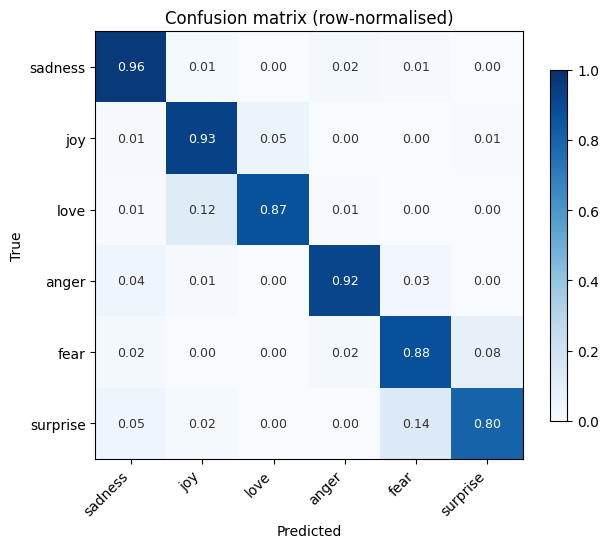

In [49]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(label_names)), label_names, rotation=45, ha="right")
ax.set_yticks(range(len(label_names)), label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalised)")

for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color="white" if cm[i, j] > 0.5 else "#333333")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
def predict_texts(texts):
    model.eval()
    enc = tokenizer(texts, truncation=True, max_length=128,
                    padding=True, return_tensors="pt")
    enc.pop("token_type_ids", None)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        probs = model(**enc).logits.softmax(-1).cpu()
    for t, p in zip(texts, probs):
        i = p.argmax().item()
        print(f"{label_names[i]:9s} {p[i]:.3f}   {t}")

predict_texts([
    "i cant believe she actually remembered my birthday",
    "my hands are shaking i have to present in five minutes",
    "why does he keep ignoring my messages",
    "i miss how things used to be between us",
])

sadness   0.477   i cant believe she actually remembered my birthday
fear      0.945   my hands are shaking i have to present in five minutes
anger     0.751   why does he keep ignoring my messages
sadness   0.604   i miss how things used to be between us


In [51]:
!pip freeze | grep -iE "^(torch|torchvision|transformers|datasets|scikit-learn|numpy|matplotlib)=="

datasets==4.0.0
matplotlib==3.10.0
numpy==2.1.3
scikit-learn==1.6.1
torch==2.11.0+cu128
torchvision==0.26.0+cu128
transformers==5.16.1
